# Load Data and Utilities

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch

import sys
import pathlib
sys.path.append(str(pathlib.Path().absolute().parent))
from diffusion import MaskedDiffusion
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from utils import collect_experiment_data

df_all = collect_experiment_data(logs_dir="../logs")

# Load U-Turn Results

In [18]:
L = 2000
l2reg = 0.01
dataset = "uniform"
model_t = "linear"
decoding = "greedy" 
num_samples = 200

# df = df_all[
#     (df_all["L"] == L) &
#     (df_all["l2reg"] == l2reg) &
#     (df_all["dataset"] == dataset) &
#     (df_all["model"] == model_t)
# ]
# assert len(df.alpha.unique()) == len(df)
# df

In [19]:
## LOAD SAVED RESULTS
df_uturn = pd.read_csv(f"res-exp-uturn_{decoding}_L{L}_l2reg{l2reg}_{dataset}_{model_t}_n{num_samples}.csv")
# df_uturn = pd.read_csv(f"res-exp-uturn_L{L}_l2reg{l2reg}_{dataset}_{model_t}_n{num_samples}.csv")
df_uturn

,decoding,alpha,t0,frac_masked,frac_correct,frac_errors
0,greedy,0.05,0.00,0.0000,1.000000,0.000000
1,greedy,0.05,0.05,0.0000,1.000000,0.000000
2,greedy,0.05,0.05,0.0005,0.999500,0.000000
3,greedy,0.05,0.05,0.0010,0.999000,0.000000
4,greedy,0.05,0.05,0.0015,0.998500,0.000000
...,...,...,...,...,...,...
420415,greedy,1.00,1.00,0.9980,0.000965,0.001035
420416,greedy,1.00,1.00,0.9985,0.000745,0.000755
420417,greedy,1.00,1.00,0.9990,0.000500,0.000500
420418,greedy,1.00,1.00,0.9995,0.000245,0.000255


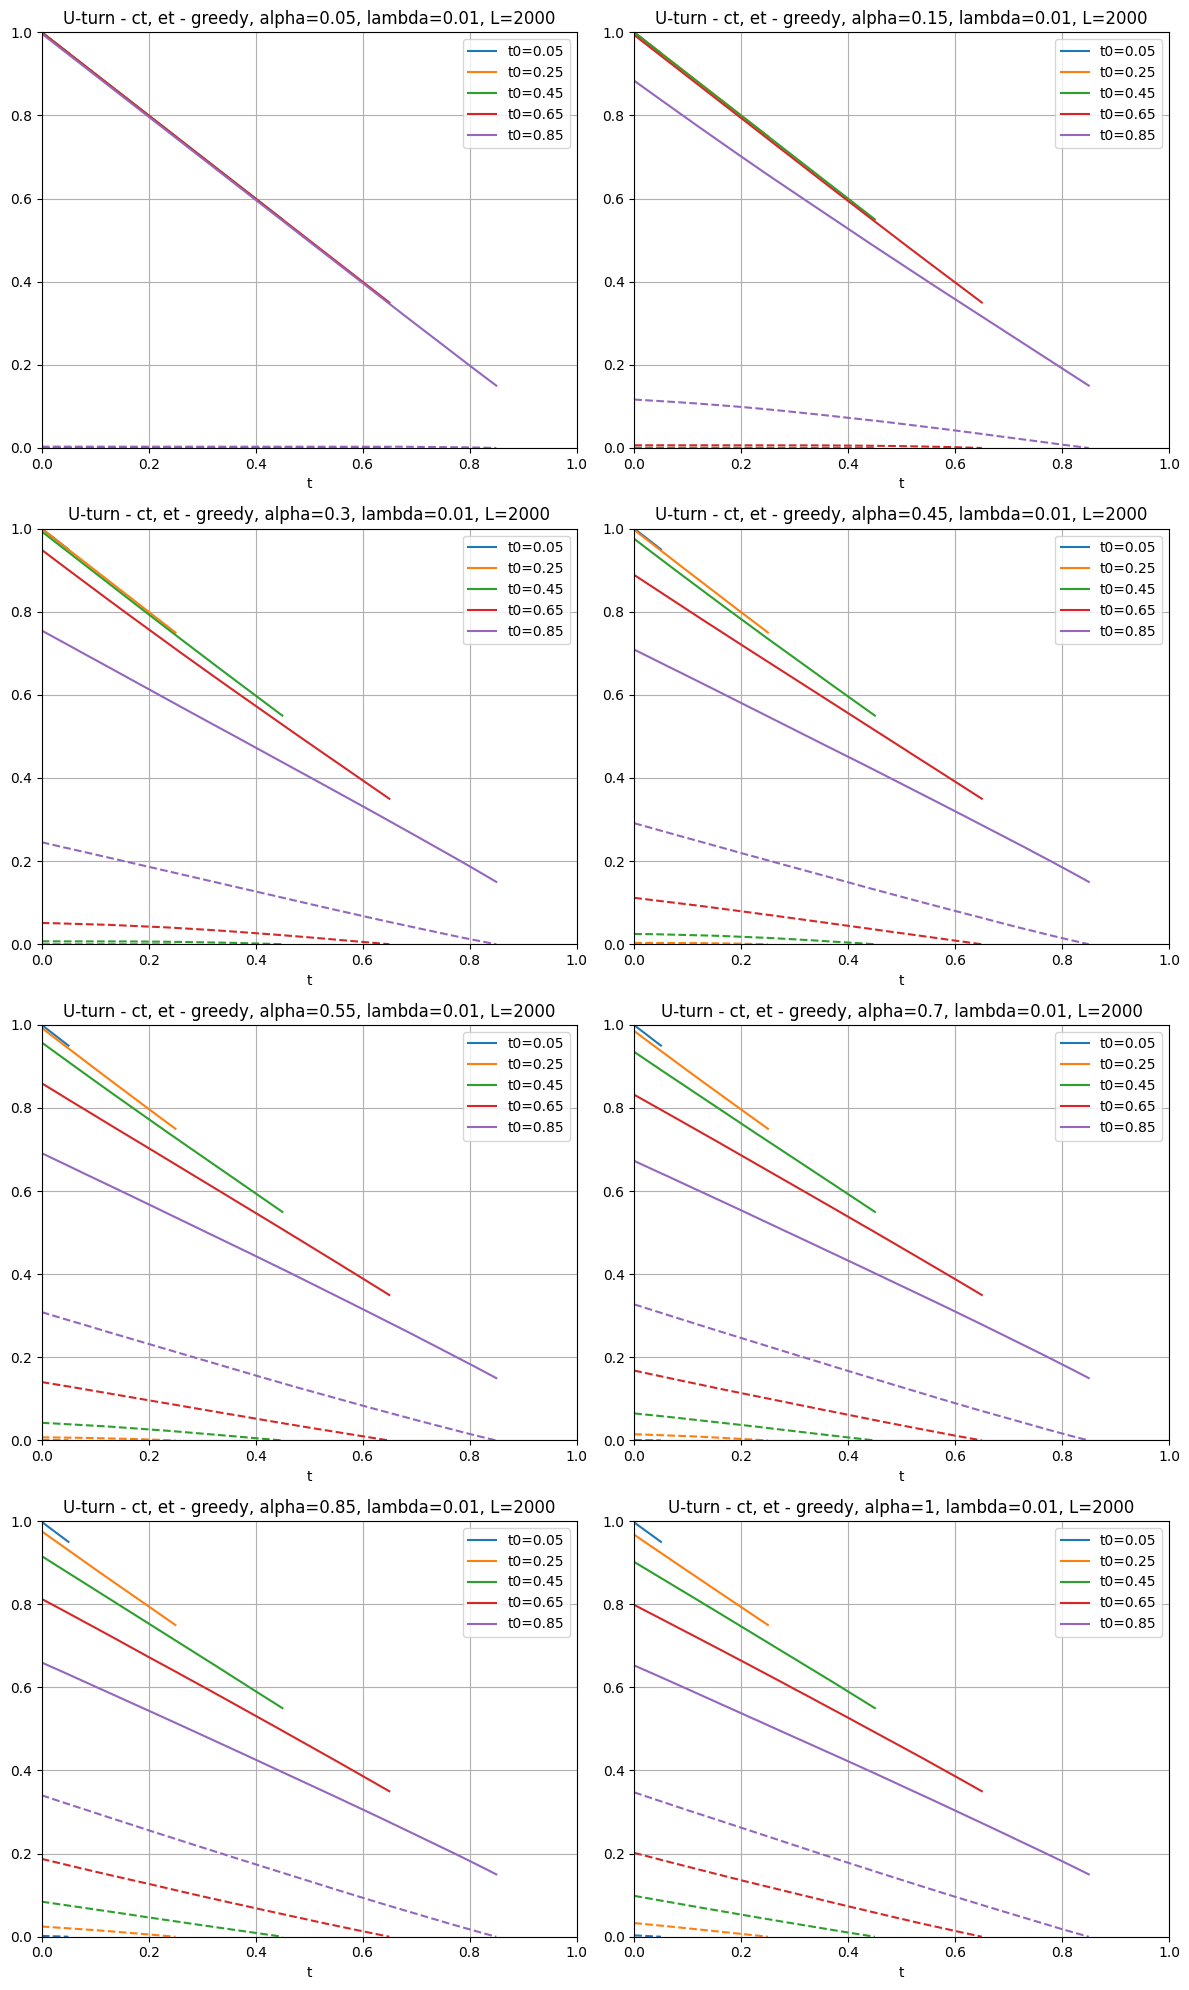

In [20]:
alphas = sorted(df_uturn[df_uturn["decoding"] == decoding]["alpha"].unique().tolist())
# pick 8 equally spaced indexes for the alpha values
alphas = [alphas[i] for i in np.linspace(0, len(alphas) - 1, 8, dtype=int)]
fig, axs = plt.subplots(4, 2, figsize=(12, 20))
axs = axs.flatten()
for alpha in alphas:
    df_alpha = df_uturn[(df_uturn["alpha"] == alpha) & (df_uturn["decoding"] == decoding)]
    ax = axs[alphas.index(alpha)]
    for t0 in np.sort(df_alpha["t0"].unique())[1::4]:
        df_t0 = df_alpha[df_alpha["t0"] == t0]
        ax.plot(df_t0["frac_masked"], df_t0["frac_correct"], label=f"t0={t0:.2f}")
        ax.plot(df_t0["frac_masked"], df_t0["frac_errors"], linestyle="dashed", color=ax.lines[-1].get_color())

    ax.set_xlabel("t")
    ax.set_title(f"U-turn - ct, et - {decoding}, alpha={alpha:g}, lambda={l2reg}, L={L}")
    ax.legend()
    ax.grid()
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(f"exp-uturn_c-vs-t_{decoding}_L{L}_l2reg{l2reg}_{dataset}_{model_t}.png")

In [21]:
df_uturn_final = df_uturn[df_uturn.frac_masked == 0]
df_uturn_final = df_uturn_final.sort_values(["decoding", "alpha", "t0"])  
df_uturn_final = df_uturn_final.reset_index(drop=True)
df_uturn_final

,decoding,alpha,t0,frac_masked,frac_correct,frac_errors
0,greedy,0.05,0.00,0.0,1.000000,0.000000
1,greedy,0.05,0.05,0.0,1.000000,0.000000
2,greedy,0.05,0.10,0.0,1.000000,0.000000
3,greedy,0.05,0.15,0.0,1.000000,0.000000
4,greedy,0.05,0.20,0.0,1.000000,0.000000
...,...,...,...,...,...,...
415,greedy,1.00,0.80,0.0,0.694538,0.305463
416,greedy,1.00,0.85,0.0,0.652660,0.347340
417,greedy,1.00,0.90,0.0,0.606760,0.393240
418,greedy,1.00,0.95,0.0,0.556835,0.443165


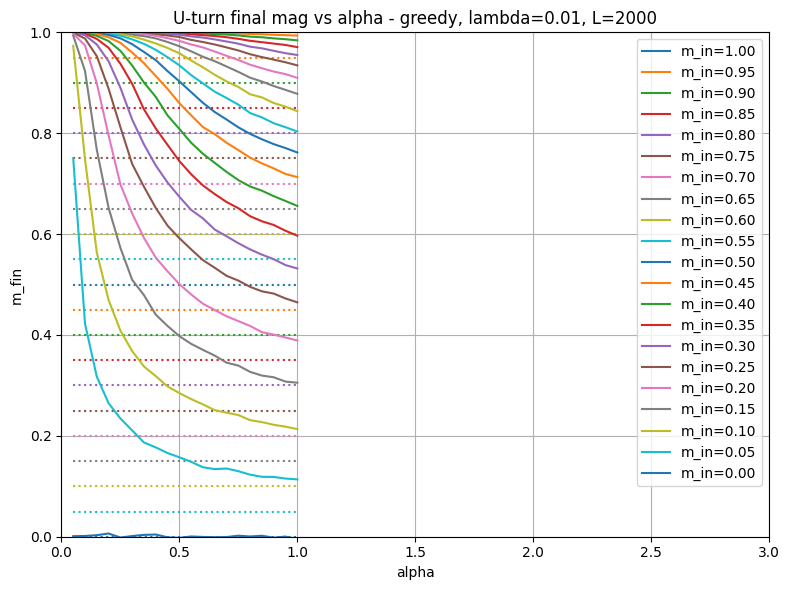

In [ ]:
dfs = df_uturn_final[df_uturn_final["decoding"] == decoding]
fig1, ax = plt.subplots(figsize=(8,6))
for t0 in np.sort(dfs["t0"].unique()):
    df_t0 = dfs[dfs["t0"] == t0]
    m_in = 1 - t0
    m_in_array = np.full_like(df_t0["alpha"], m_in)
    m_fin = df_t0["frac_correct"] - df_t0["frac_errors"]
    ax.plot(df_t0["alpha"], m_fin, label=f"m_in={m_in:.2f}")
    ax.plot(df_t0["alpha"], m_in_array, linestyle="dotted", color=ax.lines[-1].get_color())
ax.set_xlabel("alpha")
ax.set_ylabel("m_fin")
ax.set_title(f"U-turn final mag vs alpha - {decoding}, lambda={l2reg}, L={L}")
ax.legend()
ax.grid()
ax.set_xlim(0, 3)
ax.set_ylim(0., 1)
plt.tight_layout()
# plt.savefig(f"exp-uturn_mfin-vs-alpha_{decoding}_L{L}_l2reg{l2reg}_{dataset}_{model_t}.png")
plt.show()

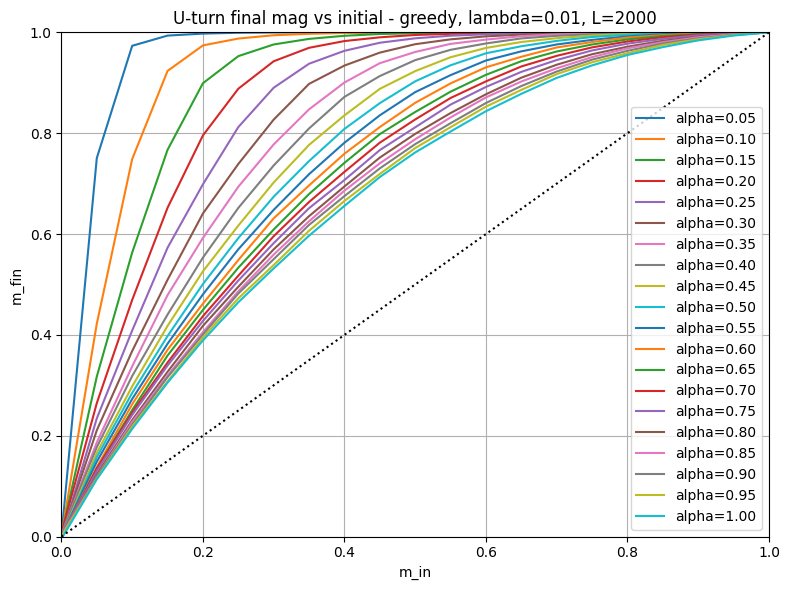

In [16]:
dfs = df_uturn_final[df_uturn_final["decoding"] == decoding]
fig2, ax = plt.subplots(figsize=(8,6))
for alpha in dfs["alpha"].unique():
    df_alpha = dfs[dfs["alpha"] == alpha]
    m_in = 1 - df_alpha["t0"]
    m_fin = df_alpha["frac_correct"] - df_alpha["frac_errors"]
    ax.plot(m_in, m_fin, label=f"alpha={alpha:.2f}")
ax.plot([0,1], [0,1], linestyle="dotted", color="black")
ax.set_xlabel("m_in")
ax.set_ylabel("m_fin")
ax.set_title(f"U-turn final mag vs initial - {decoding}, lambda={l2reg}, L={L}")
ax.legend()
ax.grid()
ax.set_xlim(0., 1)
ax.set_ylim(0., 1)
plt.tight_layout()
plt.savefig(f"exp-uturn_mfin-vs-min_{decoding}_L{L}_l2reg{l2reg}_{dataset}_{model_t}.png")
plt.show()
